In [1]:
import os
import shutil
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix, classification_report
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import kagglehub

# ==========================================
# 1. DESCARGA DE DATASETS
# ==========================================
print("--- Descargando datasets ---")
p_coffee1 = kagglehub.dataset_download("gpiosenka/coffee-bean-dataset-resized-224-x-224")
p_coffee2 = kagglehub.dataset_download("sujitraarw/coffee-green-bean-with-17-defects-original")
p_coffee3 = kagglehub.dataset_download("sultandaulay/coffee-bean-dataset")
p_coffee4 = kagglehub.dataset_download("javiersarango/coffee-roast-agtron-scale-dataset")
p_frijol = kagglehub.dataset_download("miguelangelastaiza/frijol")
p_rice = kagglehub.dataset_download("muratkokludataset/rice-image-dataset")
p_stones = kagglehub.dataset_download("vencerlanz09/shells-or-pebbles-an-image-classification-dataset")
p_horses = kagglehub.dataset_download("ifeanyinneji/donkeys-horses-zebra-images-dataset")
print("--- Datasets descargados---")

--- Descargando datasets ---
--- Datasets descargados---


In [2]:

# ==========================================
# 2. ORGANIZACIÓN FÍSICA (Train/Val)
# ==========================================
base_dir = '/kaggle/working/dataset'
for split in ['train', 'val']:
    for cat in ['coffee', 'not_coffee']:
        os.makedirs(os.path.join(base_dir, split, cat), exist_ok=True)

def get_images(path, subfilter=None):
    valid = []
    for root, _, files in os.walk(path):
        if subfilter and subfilter not in root: continue
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg','.JPEG')):
                valid.append(os.path.join(root, f))
    return valid

# Recolectar rutas
coffee_list = get_images(p_coffee1) + get_images(p_coffee2) + get_images(p_coffee3) + get_images(p_coffee4)
not_coffee_list = get_images(p_frijol, "Buenos") + get_images(p_rice) + get_images(p_stones, "Pebbles") + get_images(p_horses, "train/horse")

# Balanceo y División (80% train, 20% val)
# Limitamos a 5000 por clase para robustez y velocidad
target = min(len(coffee_list), len(not_coffee_list), 5000)
train_count = int(target * 0.8)

def distribute_images(imgs, label):
    random.shuffle(imgs)
    # Train
    for i, p in enumerate(imgs[:train_count]):
        shutil.copy(p, os.path.join(base_dir, 'train', label, f"{label}_{i}.jpg"))
    # Val
    for i, p in enumerate(imgs[train_count:target]):
        shutil.copy(p, os.path.join(base_dir, 'val', label, f"{label}_{i}.jpg"))

distribute_images(coffee_list, 'coffee')
distribute_images(not_coffee_list, 'not_coffee')

print(f" Dataset estructurado: {train_count*2} train, {(target-train_count)*2} val.")





 Dataset estructurado: 8000 train, 2000 val.



--- Visualización de Muestras Iniciales ---


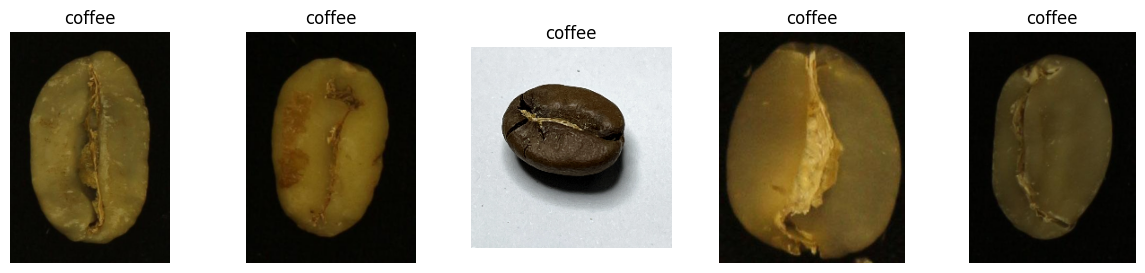

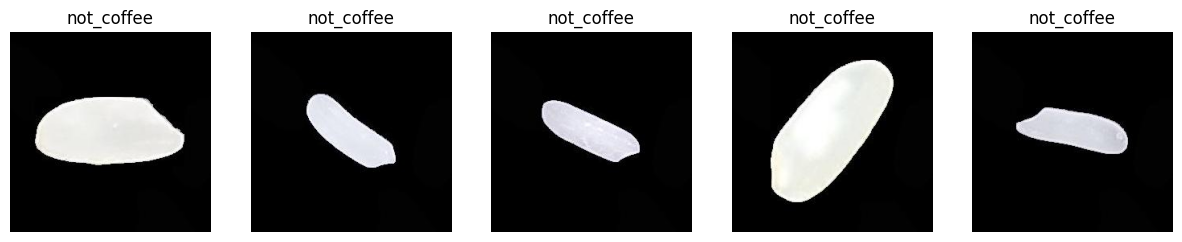

In [3]:
# ==========================================
# 3. VISUALIZACIÓN INICIAL (EDA)
# ==========================================
def plot_samples(category, n=5):
    folder = os.path.join(base_dir, 'train', category)
    available_files = os.listdir(folder)
    imgs = random.sample(available_files, min(n, len(available_files)))
    plt.figure(figsize=(15, 3))
    for i, img_name in enumerate(imgs):
        plt.subplot(1, n, i+1)
        img = Image.open(os.path.join(folder, img_name))
        plt.imshow(img)
        plt.title(category)
        plt.axis('off')
    plt.show()

print("\n--- Visualización de Muestras Iniciales ---")
plot_samples('coffee')
plot_samples('not_coffee')

In [4]:
transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_data = datasets.ImageFolder(
    os.path.join(base_dir, 'train'),
    transform=transform
)

val_data = datasets.ImageFolder(
    os.path.join(base_dir, 'val'),
    transform=transform
)

train_loader = DataLoader(
    train_data,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_data,
    batch_size=128,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

# --- CARGA DEL MODELO CONVNEXT ---
try:
    from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
    weights = ConvNeXt_Tiny_Weights.IMAGENET1K_V1
    model = convnext_tiny(weights=weights)
    print("ConvNeXt-Tiny cargado con Weights API")
except (ImportError, AttributeError):
    model = models.convnext_tiny(pretrained=True)
    print("ConvNeXt-Tiny cargado con pretrained=True (Legacy API)")

# CONGELAR BACKBONE
for param in model.parameters():
    param.requires_grad = False

# REEMPLAZAR CLASIFICADOR (SALIDA BINARIA)
model.classifier[2] = nn.Linear(
    model.classifier[2].in_features,
    1
)

# ENVIAR A GPU
model = model.to(device)

# LOSS Y OPTIMIZADOR (SOLO HEAD)
criterion = nn.BCEWithLogitsLoss()

optimizer = optim.Adam(
    model.classifier.parameters(),
    lr=1e-3
)


Usando dispositivo: cuda
Downloading: "https://download.pytorch.org/models/convnext_tiny-983f1562.pth" to /root/.cache/torch/hub/checkpoints/convnext_tiny-983f1562.pth


100%|██████████| 109M/109M [00:00<00:00, 207MB/s] 


ConvNeXt-Tiny cargado con Weights API


In [5]:
epochs =10
scaler = torch.amp.GradScaler()
history = {
    'train_loss': [],
    'val_loss': [],
    'train_acc': [],
    'val_acc': []
}
print("\n--- Iniciando Entrenamiento ---")
for epoch in range(epochs):
    model.train()
    t_loss, t_correct = 0, 0

    for inputs, labels in train_loader:
        inputs = inputs.to(device, non_blocking=True)
        labels = labels.to(device).float().view(-1, 1)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        preds = (torch.sigmoid(outputs) > 0.5).float()
        t_loss += loss.item()
        t_correct += (preds == labels).sum().item()

    # -------- VALIDACIÓN --------
    model.eval()
    v_loss, v_correct = 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs = inputs.to(device, non_blocking=True)
            labels = labels.to(device).float().view(-1, 1)

            with torch.amp.autocast("cuda"):
                outputs = model(inputs)
                loss = criterion(outputs, labels)

            preds = (torch.sigmoid(outputs) > 0.5).float()
            v_loss += loss.item()
            v_correct += (preds == labels).sum().item()

    print(
        f"Época {epoch+1} | "
        f"Train Acc: {t_correct/len(train_data):.3f} | "
        f"Val Acc: {v_correct/len(val_data):.3f}"
    )
    history['train_loss'].append(t_loss / len(train_loader))
    history['val_loss'].append(v_loss / len(val_loader))
    history['train_acc'].append(t_correct / len(train_data))
    history['val_acc'].append(v_correct / len(val_data))
    # -------- PASO A FASE 2 --------
    if epoch == 4:
        print("Descongelando últimos bloques de ConvNeXt")
        for param in model.features[-2:].parameters():
            param.requires_grad = True

        optimizer = optim.AdamW(
            filter(lambda p: p.requires_grad, model.parameters()),
            lr=1e-4
        )


--- Iniciando Entrenamiento ---
Época 1 | Train Acc: 0.954 | Val Acc: 0.992
Época 2 | Train Acc: 0.992 | Val Acc: 0.996
Época 3 | Train Acc: 0.995 | Val Acc: 0.997
Época 4 | Train Acc: 0.997 | Val Acc: 0.998
Época 5 | Train Acc: 0.997 | Val Acc: 0.999
Descongelando últimos bloques de ConvNeXt
Época 6 | Train Acc: 0.999 | Val Acc: 1.000
Época 7 | Train Acc: 1.000 | Val Acc: 1.000
Época 8 | Train Acc: 1.000 | Val Acc: 1.000
Época 9 | Train Acc: 1.000 | Val Acc: 1.000
Época 10 | Train Acc: 1.000 | Val Acc: 1.000


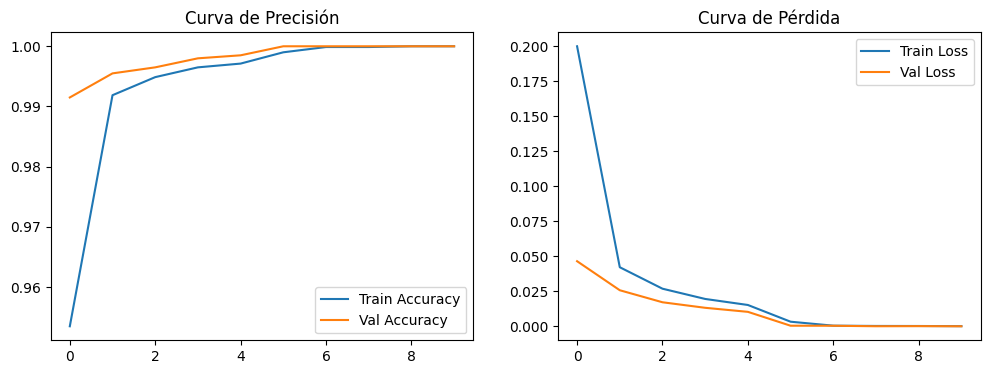

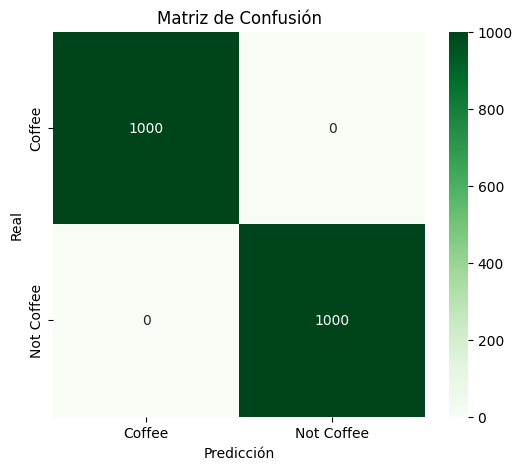


--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      Coffee       1.00      1.00      1.00      1000
  Not Coffee       1.00      1.00      1.00      1000

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



In [6]:
# 6. MÉTRICAS FINALES Y GRÁFICAS
# ==========================================
all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        preds = (torch.sigmoid(outputs) > 0.5).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

# Gráficas
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Curva de Precisión')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Curva de Pérdida')
plt.legend()
plt.savefig('grafica_entrenamiento.png')
plt.show()

# Matriz de Confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Coffee', 'Not Coffee'], yticklabels=['Coffee', 'Not Coffee'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.savefig('matriz_confusion.png')
plt.show()

print("\n--- Reporte de Clasificación ---")
print(classification_report(all_labels, all_preds, target_names=['Coffee', 'Not Coffee']))




--- Probando inferencia con una imagen aleatoria del set de validación ---


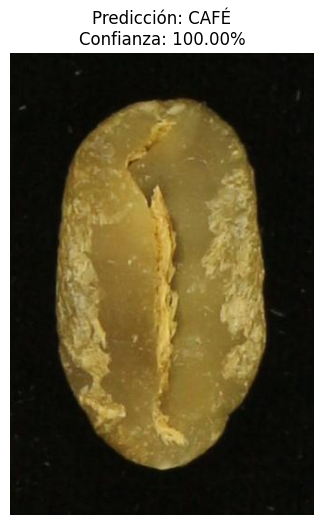

In [7]:
import torch.nn.functional as F

def realizar_inferencia(image_path, model, device):
    """
    Carga una imagen, la procesa y realiza la predicción con el modelo.
    """
    if not os.path.exists(image_path):
        print(f"Error: No se encontró el archivo en {image_path}")
        return

    # 1. Definir las mismas transformaciones del entrenamiento
    inference_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # 2. Cargar y transformar la imagen
    img_original = Image.open(image_path).convert('RGB')
    img_tensor = inference_transform(img_original).unsqueeze(0).to(device)

    # 3. Realizar predicción
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        # Aplicamos Sigmoid ya que usamos BCEWithLogitsLoss
        probabilidad = torch.sigmoid(output).item()
    
    # 4. Determinar etiqueta (0: Coffee, 1: Not Coffee basado en orden alfabético)
    if probabilidad < 0.5:
        label = "CAFÉ"
        confianza = (1 - probabilidad) * 100
    else:
        label = "NO ES CAFÉ (Frijol/Piedra/Arroz)"
        confianza = probabilidad * 100

    # 5. Mostrar resultado visual
    plt.figure(figsize=(6, 6))
    plt.imshow(img_original)
    plt.title(f"Predicción: {label}\nConfianza: {confianza:.2f}%")
    plt.axis('off')
    plt.show()

# =============================================================
# EJEMPLO DE USO MANUAL
# =============================================================

# 1. Si quieres probar con una imagen que acabas de subir:
# ruta_mi_imagen = '/kaggle/working/tu_foto_subida.jpg' 
# realizar_inferencia(ruta_mi_imagen, model, device)

# 2. Ejemplo automático: Probar con una imagen aleatoria del set de validación
print("\n--- Probando inferencia con una imagen aleatoria del set de validación ---")
folder_test = os.path.join(base_dir, 'val')
clase_random = random.choice(['coffee', 'not_coffee'])
img_random = random.choice(os.listdir(os.path.join(folder_test, clase_random)))
ruta_prueba = os.path.join(folder_test, clase_random, img_random)

realizar_inferencia(ruta_prueba, model, device)


--- Probando inferencia con una imagen aleatoria del set de validación ---


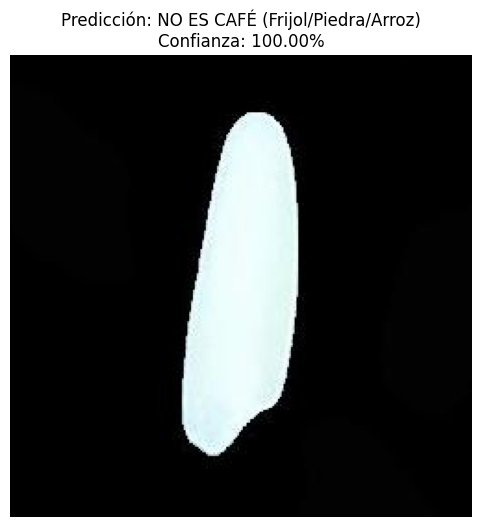

In [8]:
# =============================================================
# EJEMPLO DE USO MANUAL
# =============================================================

# 1. Si quieres probar con una imagen que acabas de subir:
# ruta_mi_imagen = '/kaggle/working/tu_foto_subida.jpg' 
# realizar_inferencia(ruta_mi_imagen, model, device)

# 2. Ejemplo automático: Probar con una imagen aleatoria del set de validación
print("\n--- Probando inferencia con una imagen aleatoria del set de validación ---")
folder_test = os.path.join(base_dir, 'val')
clase_random = random.choice(['coffee', 'not_coffee'])
img_random = random.choice(os.listdir(os.path.join(folder_test, clase_random)))
ruta_prueba = os.path.join(folder_test, clase_random, img_random)

realizar_inferencia(ruta_prueba, model, device)

In [9]:
import requests
from io import BytesIO

def realizar_inferencia_flexible(input_path, model, device):
    """
    Realiza una predicción recibiendo una ruta local o una URL de internet.
    """
    # 1. Definir las transformaciones (deben ser las mismas del entrenamiento)
    inference_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    try:
        # 2. Cargar la imagen (desde URL o local)
        if input_path.startswith('http'):
            print(f"🌐 Descargando imagen desde URL...")
            response = requests.get(input_path, timeout=10)
            img_original = Image.open(BytesIO(response.content)).convert('RGB')
        else:
            print(f"Cargando imagen local...")
            img_original = Image.open(input_path).convert('RGB')
        
        # 3. Preprocesar
        img_tensor = inference_transform(img_original).unsqueeze(0).to(device)

        # 4. Predicción
        model.eval()
        with torch.no_grad():
            output = model(img_tensor)
            probabilidad = torch.sigmoid(output).item()
        
        # 5. Mapeo de resultados
        # 0: coffee, 1: not_coffee (por orden alfabético de carpetas)
        if probabilidad < 0.5:
            label = "ES CAFÉ"
            confianza = (1 - probabilidad) * 100
            color = 'green'
        else:
            label = "NO ES CAFÉ"
            confianza = probabilidad * 100
            color = 'red'

        # 6. Mostrar resultado
        plt.figure(figsize=(6, 6))
        plt.imshow(img_original)
        plt.title(f"Resultado: {label}\nConfianza: {confianza:.2f}%", color=color, fontsize=14, fontweight='bold')
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Error al procesar la imagen: {e}")

# =============================================================
# ESPACIO PARA TUS PRUEBAS 
# =============================================================



# OPCIÓN B: Usar una ruta local (si subiste un archivo a Kaggle)
# mi_ruta_local = "/kaggle/working/mi_foto.jpg"
# realizar_inferencia_flexible(mi_ruta_local, model, device)


🌐 Descargando imagen desde URL...


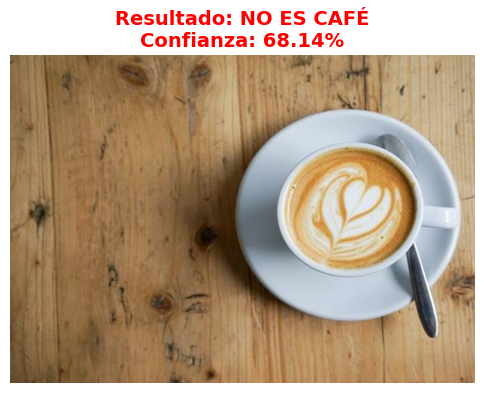

In [12]:
# OPCIÓN A: Usar una URL de internet
mi_enlace = "https://a.storyblok.com/f/112937/568x400/65868734b8/coffee-around-the-world-what-to-order-where-square-568x400.jpg/m/620x0/filters:quality(70)/" # Ejemplo de granos
realizar_inferencia_flexible(mi_enlace, model, device)

In [ ]:
# ==========================================
# 7. GUARDAR Y EMPAQUETAR
# ==========================================
# Guardar pesos del modelo
torch.save(model.state_dict(), 'modelo_cafe_binario.pth')

# Crear ZIP del dataset (incluye carpetas train y val)
#print("\n--- Creando archivo ZIP del dataset (esto puede tardar) ---")
#shutil.make_archive('dataset_entrenamiento_final', 'zip', base_dir)
